# Strojenie Hiperparametrów (Hyperparameter Tuning)

Notatnik ten prezentuje proces analizy optymalizacji hiperparametrów (Hyperparameter Optimization - HPO) dla badanych modeli. 
W bibliotece RecBole optymalizacja najczęściej odbywa się z poziomu dedykowanych skryptów (np. `run_hyper_bpr.py`), ponieważ przeszukiwanie siatki (Grid Search) lub losowe (Random Search) bywa procesem trwającym dziesiątki godzin. 

W tym notatniku wczytamy zapisane logi z wynikami optymalizacji, przekształcimy je do postaci tabelarycznej i wizualnie ocenimy, **jak poszczególne parametry wpływają na jakość modelu** (np. metrykę NDCG@10).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Wczytanie i parsowanie wyników z plików `.result`
Biblioteka RecBole zapisuje wyniki poszczególnych iteracji strojenia w bardzo specyficznym formacie tekstowym. Napiszmy funkcję, która wyciągnie z nich parametry wejściowe oraz wynik testowy `ndcg@10`.

In [2]:
def parse_hyper_result(filepath):
    results = []
    if not os.path.exists(filepath):
        print(f"Brak pliku: {filepath}")
        return pd.DataFrame()
        
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.read().strip().split('\n\n')
        
    for block in lines:
        parts = block.split('\n')
        if len(parts) >= 5:
            # Parsowanie hiperparametrów, np: "embedding_size:512, learning_rate:0.001"
            params_str = parts[0]
            params = {k.strip(): float(v.strip()) for k, v in (item.split(':') for item in params_str.split(','))}
            
            # Parsowanie wyniku testowego (linijka 4 licząc od 0)
            test_result_str = parts[4]
            ndcg_match = re.search(r"ndcg@10\s*:\s*([0-9\.]+)", test_result_str)
            if ndcg_match:
                params['Test_NDCG@10'] = float(ndcg_match.group(1))
                results.append(params)
                
    df = pd.DataFrame(results)
    # Sortowanie od najlepszego
    if not df.empty:
        df = df.sort_values(by='Test_NDCG@10', ascending=False).reset_index(drop=True)
    return df

# Przykładowe parsowanie wyników dla modelu BPR
df_hyper_bpr = parse_hyper_result('../3_Evaluation/Reports/hyper_results_bpr.result')
display(df_hyper_bpr.head(5).style.background_gradient(subset=['Test_NDCG@10'], cmap='Greens'))

,embedding_size,learning_rate,train_batch_size,Test_NDCG@10
0,512.000000,0.001000,4096.000000,0.290500
1,256.000000,0.001000,4096.000000,0.285400
2,128.000000,0.001000,4096.000000,0.283700
3,64.000000,0.001000,2048.000000,0.281500
4,64.000000,0.010000,4096.000000,0.260400


## 2. Analiza Wpływu Learning Rate (Szybkości Uczenia)
Zarówno za wysoki, jak i za niski *learning rate* może zepsuć wynik. Zobaczmy, jaka wartość sprawdzała się najlepiej podczas strojenia.

C:\Users\jakub\AppData\Local\Temp\ipykernel_34108\3087862656.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hyper_bpr, x='learning_rate', y='Test_NDCG@10', palette='Set2')


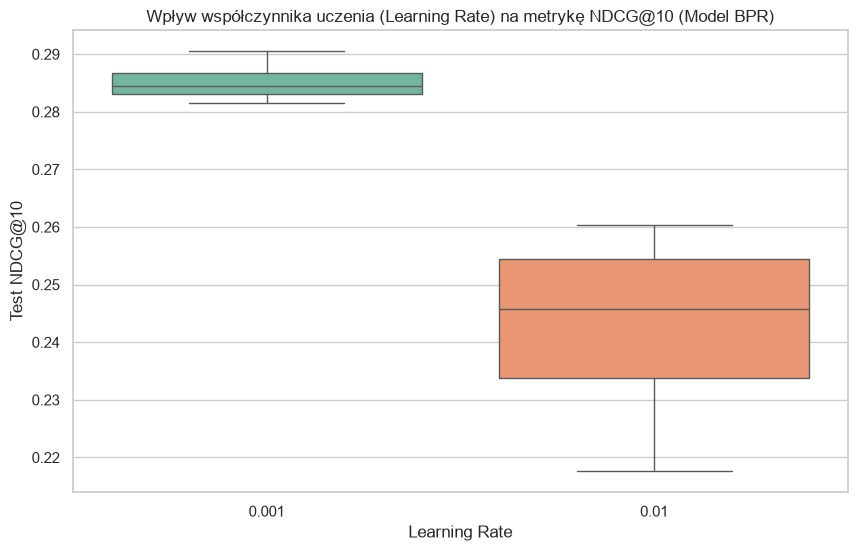

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_hyper_bpr, x='learning_rate', y='Test_NDCG@10', palette='Set2')
plt.title('Wpływ współczynnika uczenia (Learning Rate) na metrykę NDCG@10 (Model BPR)')
plt.xlabel('Learning Rate')
plt.ylabel('Test NDCG@10')
plt.show()

## 3. Analiza Wpływu Wielkości Wektora (Embedding Size)
Sprawdzamy, czy większa przestrzeń na wiedzę modelu (np. 512) zawsze przekłada się na lepsze wyniki, czy może prowadzi do przeuczenia.

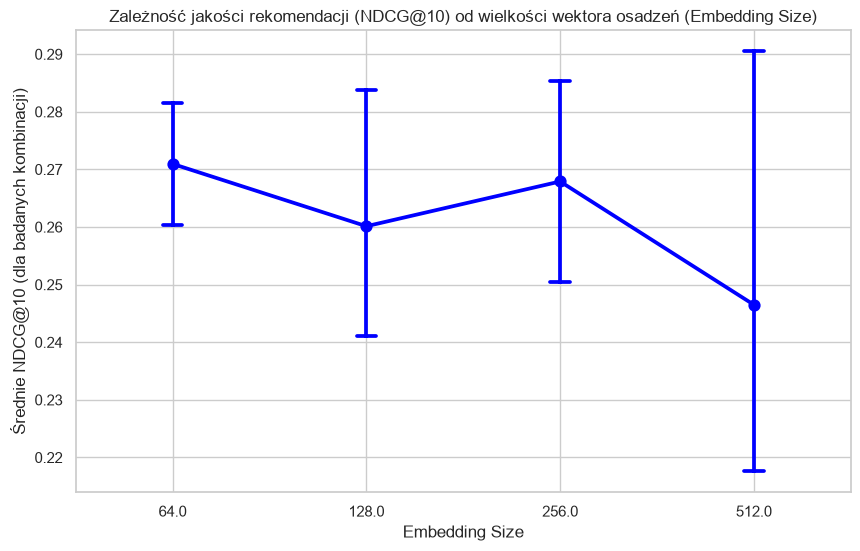

In [4]:
plt.figure(figsize=(10, 6))
sns.pointplot(data=df_hyper_bpr, x='embedding_size', y='Test_NDCG@10', capsize=.1, color='blue')
plt.title('Zależność jakości rekomendacji (NDCG@10) od wielkości wektora osadzeń (Embedding Size)')
plt.xlabel('Embedding Size')
plt.ylabel('Średnie NDCG@10 (dla badanych kombinacji)')
plt.grid(True)
plt.show()

## 4. Wizualizacja przestrzeni parametrów (Heatmapa)
Możemy zgrupować wyniki, aby sprawdzić, która dokładnie kombinacja dwóch parametrów okazała się najlepsza.

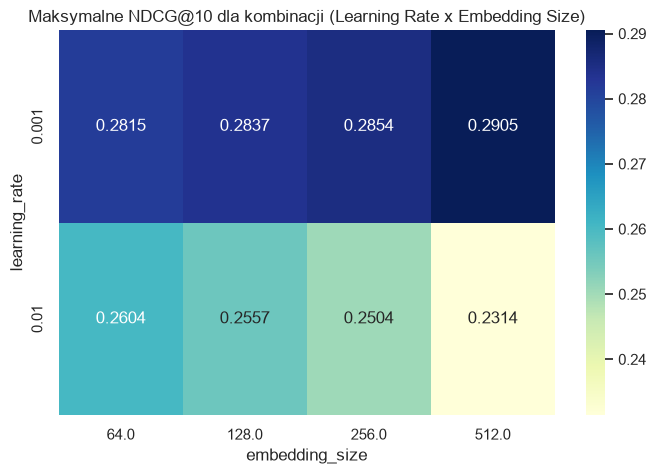

In [5]:
heatmap_data = df_hyper_bpr.pivot_table(index='learning_rate', columns='embedding_size', values='Test_NDCG@10', aggfunc='max')

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title('Maksymalne NDCG@10 dla kombinacji (Learning Rate x Embedding Size)')
plt.show()